In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [2]:
article_df = pd.read_csv("articles_hm.csv")
customer_df = pd.read_csv("customer_hm.csv")
transaction_df = pd.read_csv("transactions_hm.csv")

In [3]:
whole_df = pd.merge(
    pd.merge(
        transaction_df,
        customer_df,
        on = 'customer_id'
    ),
    article_df,
    on ='article_id'
)
df = whole_df[['t_dat','customer_id','Active','age','section_no','section_name','index_group_no','index_group_name','product_type_no','product_type_name','price']].copy()
df['price'] = df['price']*1000

## 이원 ANOVA 

1. 이원분산 분석에서는 가설이 총 3개가 한번에 같이 검정됨. 

1 ) 연령
- 귀무가설 : 연령대별로 평균 가격이 동일하다
- 대립가설 : 연령대별로 평균 가격이 다르다. 

2 ) 카테고리
- 귀무가설 : 카테고리별로 평균 가격이 동일하다. 
- 대립가설 : 카테고리별로 평균 가격이 다르다. 

3 ) 연령 & 카테고리(상호작용 효과)
- 귀무가설 : 상호작용 효과가 없다. 
- 대립가설 : 상호작용 효과가 있다. 

In [4]:
df['age_group']= df['age']/10
df['age_group']= df['age_group'].astype(int)

In [5]:
test_df = df.loc[(df['age_group'].isin([2,3,4]))&(df['product_type_name'].isin(['Sweater','Trousers']))]
cust_df = test_df.groupby(["customer_id",'age_group','product_type_name'])['price'].mean()

In [6]:
cust_df = cust_df.reset_index()

In [7]:
cust_df.head()

,customer_id,age_group,product_type_name,price
0,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2,Trousers,50.83
1,0000ae1bbb25e04bdc7e35f718e852adfb3fbb72ef38b3...,2,Trousers,24.39
2,0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c91...,3,Sweater,16.93
3,0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c91...,3,Trousers,29.64
4,000172a9c322560c849754ffbdfdb2180d408aa7176b94...,4,Trousers,15.39


In [8]:
cust_df_20_trousers = cust_df.loc[(cust_df['age_group']==2)&(cust_df['product_type_name']=='Trousers'),'price']
cust_df_30_trousers = cust_df.loc[(cust_df['age_group']==3)&(cust_df['product_type_name']=='Trousers'),'price']
cust_df_40_trousers = cust_df.loc[(cust_df['age_group']==4)&(cust_df['product_type_name']=='Trousers'),'price']
cust_df_20_sweater = cust_df.loc[(cust_df['age_group']==2)&(cust_df['product_type_name']=='Sweater'),'price']
cust_df_30_sweater = cust_df.loc[(cust_df['age_group']==3)&(cust_df['product_type_name']=='Sweater'),'price']
cust_df_40_sweater = cust_df.loc[(cust_df['age_group']==4)&(cust_df['product_type_name']=='Sweater'),'price']

In [9]:
len(cust_df_20_trousers),len(cust_df_30_trousers),len(cust_df_40_trousers),len(cust_df_20_sweater),len(cust_df_30_sweater),len(cust_df_40_sweater)

(30801, 15860, 13717, 23801, 10839, 9244)

In [10]:
sample_size = min(len(cust_df_20_trousers), len(cust_df_30_trousers), len(cust_df_40_trousers), len(cust_df_20_sweater), len(cust_df_30_sweater), len(cust_df_40_sweater))
sample_size

9244

In [11]:
sample_20_trousers = cust_df_20_trousers.sample(sample_size, random_state=42)
sample_30_trousers = cust_df_30_trousers.sample(sample_size, random_state=42)
sample_40_trousers = cust_df_40_trousers.sample(sample_size, random_state=42)
sample_20_sweater = cust_df_20_sweater.sample(sample_size, random_state=42)
sample_30_sweater = cust_df_30_sweater.sample(sample_size, random_state=42)
sample_40_sweater = cust_df_40_sweater.sample(sample_size, random_state=42)

2. 검정방법 선택
- 정규성
- 등분산성

c:\basic_class_통계_수업\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


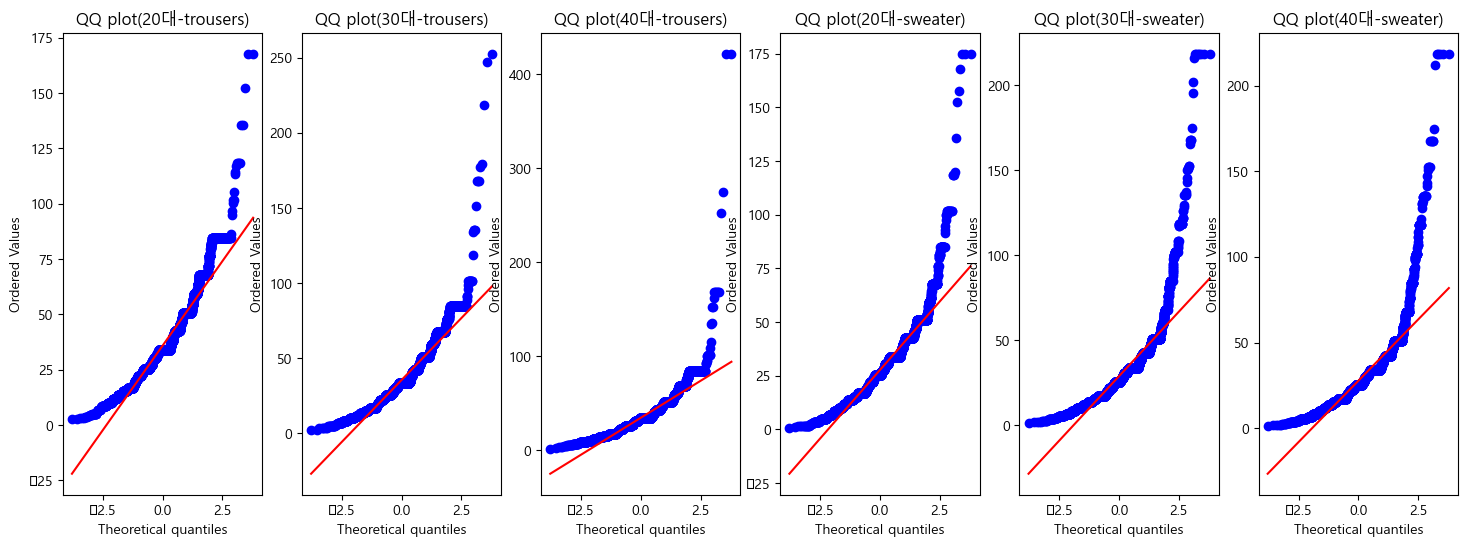

In [12]:
## q-q plot

fig, ax = plt.subplots(1,6, figsize=(18,6))
stats.probplot(sample_20_trousers, plot=ax[0])
ax[0].set_title("QQ plot(20대-trousers)")
stats.probplot(sample_30_trousers, plot=ax[1])
ax[1].set_title("QQ plot(30대-trousers)")
stats.probplot(sample_40_trousers, plot=ax[2])
ax[2].set_title("QQ plot(40대-trousers)")
stats.probplot(sample_20_sweater, plot=ax[3])
ax[3].set_title("QQ plot(20대-sweater)")
stats.probplot(sample_30_sweater, plot=ax[4])
ax[4].set_title("QQ plot(30대-sweater)")
stats.probplot(sample_40_sweater, plot=ax[5])
ax[5].set_title("QQ plot(40대-sweater)")
plt.show()

정규성 불만족 -> 로그 변환

In [13]:
sample_20_sweater_log = np.log(sample_20_sweater)
sample_30_sweater_log = np.log(sample_30_sweater)
sample_40_sweater_log = np.log(sample_40_sweater)
sample_20_trousers_log = np.log(sample_20_trousers)
sample_30_trousers_log = np.log(sample_30_trousers)
sample_40_trousers_log = np.log(sample_40_trousers)


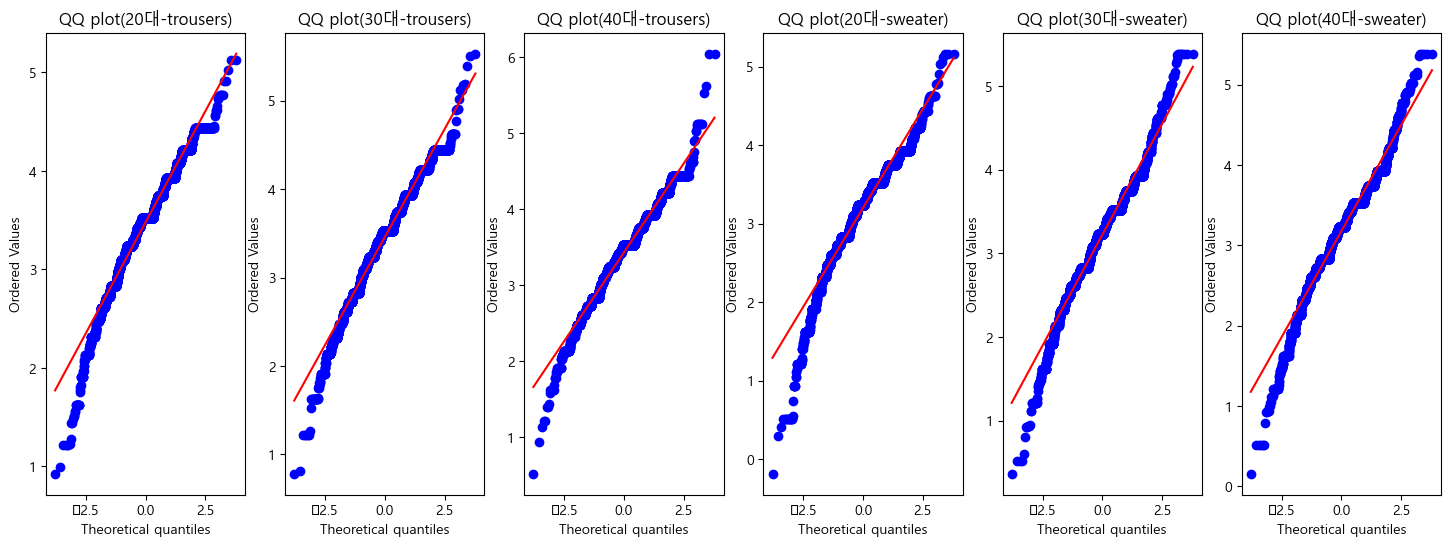

In [14]:
## q-q plot

fig, ax = plt.subplots(1,6, figsize=(18,6))
stats.probplot(sample_20_trousers_log, plot=ax[0])
ax[0].set_title("QQ plot(20대-trousers)")
stats.probplot(sample_30_trousers_log, plot=ax[1])
ax[1].set_title("QQ plot(30대-trousers)")
stats.probplot(sample_40_trousers_log, plot=ax[2])
ax[2].set_title("QQ plot(40대-trousers)")
stats.probplot(sample_20_sweater_log, plot=ax[3])
ax[3].set_title("QQ plot(20대-sweater)")
stats.probplot(sample_30_sweater_log, plot=ax[4])
ax[4].set_title("QQ plot(30대-sweater)")
stats.probplot(sample_40_sweater_log, plot=ax[5])
ax[5].set_title("QQ plot(40대-sweater)")

plt.show()

In [15]:
# 정규성 검정 Kolmogrov Sminov

def ks_test(group):
    
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    stat, p = stats.kstest(group,'norm', args=(sample_mean, s))
    return p

In [17]:
sample_lst = [sample_20_trousers_log, sample_30_trousers_log, sample_40_trousers_log, sample_20_sweater_log, sample_30_sweater_log, sample_40_sweater_log]

In [19]:
for sample in sample_lst:
    print(ks_test(sample))

1.764055572956654e-71
2.594474950785518e-58
3.818295905980351e-68
1.1762841868616168e-86
1.8451130131653686e-44
2.1087223779106076e-56


6개의 데이터 모두 정규성을 만족하지 않는다. -> 가설을 각각 나눠서 kruskal-wallis 진행 

### 만약, 정규성을 만족했다면? 

등분산성 확인 

In [21]:
stat, p = stats.levene(*sample_lst)
stat, p

(np.float64(69.14924674527288), np.float64(2.442987985459108e-72))

- 정규성 만족, 등분산성 만족 -> 이원ANOVA / Tukey
- 정규성 만족, 등분산성 불만족 -> Robust ANOVA / Games-Howell
- 정규성 불만족 -> 가설을 나눠서 Kruskal-Wallis(일원 anova처럼) /dunn

- price / 연령대 / category(trousers or Sweater)

In [22]:
np.reshape(sample_lst, shape=[-1,])

array([3.01170572, 5.12275259, 3.29959627, ..., 2.82921731, 3.52286489,
       4.43945573], shape=(55464,))

In [23]:
data = pd.DataFrame({
    'price': np.reshape(sample_lst, shape=[-1,]),
    'age': ['20']*sample_size+['30']*sample_size+['40']*sample_size+['20']*sample_size+['30']*sample_size+['40']*sample_size,
    'category': ['trousers']*3*sample_size+['sweater']*3*sample_size  
})

In [24]:
import statsmodels.formula.api as smf

In [25]:
model =smf.ols("price ~ C(age) * C(category)", data=data).fit()

rob = model.get_robustcov_results(cov_type="HC3")

print(rob.wald_test_terms())

                                         F                     P>F  df constraint  df denom
Intercept           [[357233.67096117616]]                     0.0              1  55458.00
C(age)               [[14.64056488594069]]  4.3990755764791896e-07              2  55458.00
C(category)         [[1521.5942868345721]]                     0.0              1  55458.00
C(age):C(category)   [[8.335068311974988]]   0.0002402535238886534              2  55458.00


c:\basic_class_통계_수업\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


사후검정

In [26]:
import pingouin as pg

result = pg.pairwise_gameshowell(data=data, dv = 'price', between='age')
result

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,20,30,3.34,3.34,0.00,0.01,0.22,36907.98,0.97,0.00
1,20,40,3.34,3.31,0.04,0.01,6.80,36945.14,0.00,0.07
2,30,40,3.34,3.31,0.04,0.01,6.45,36966.38,0.00,0.07


In [27]:
result = pg.pairwise_gameshowell(data=data, dv = 'price', between='category')
result

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,sweater,trousers,3.20,3.46,-0.26,0.00,-60.07,54805.88,0.00,-0.51


### 정규성과 등분산성 모두 만족

In [28]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols("price ~ age + category + age:category", data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

               sum_sq       df       F  PR(>F)
age             15.76     2.00   31.25    0.00
category       911.24     1.00 3612.77    0.00
age:category     4.14     2.00    8.20    0.00
Residual     13988.06 55458.00     NaN     NaN


사후검정: Tukey

In [29]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog = data['price'], groups=data['age'], alpha=0.01)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.01 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    20     30  -0.0012 0.9746 -0.0169  0.0145  False
    20     40  -0.0363    0.0  -0.052 -0.0206   True
    30     40  -0.0352    0.0 -0.0509 -0.0195   True
----------------------------------------------------


In [30]:
tukey = pairwise_tukeyhsd(endog = data['price'], groups=data['category'], alpha=0.01)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.01 
 group1  group2  meandiff p-adj lower  upper  reject
----------------------------------------------------
sweater trousers   0.2564   0.0 0.2454 0.2673   True
----------------------------------------------------


# 비율검정

## 단일

1. 귀무가설 : 전체 고객 중 드레스를 구매한 고객은 17%이다. 
2. 대립가설 : 전체 고객 중 드레스를 구매한 고객은 17%보다 크다 

In [31]:
cust_dress_df = pd.crosstab(df['customer_id'],df['product_type_name'])['Dress']
cust_dress_df = cust_dress_df.apply(lambda x: 1 if x>=1 else 0)

In [32]:
cust_dress_df.sum()/ len(cust_dress_df)

n = len(cust_dress_df) # 전체 고객 수
r = cust_dress_df.sum() #드레스 구매한 사람 수

n, r

(353560, np.int64(63562))

조건 확인 
n * 0.17 > 5 , n*0.83 > 5

In [33]:
n * 0.17 > 5 , n*0.83 > 5

(True, True)

In [34]:
from statsmodels.stats.proportion import proportions_ztest

# 귀무가설 비율
value = 0.17

stat, pval = proportions_ztest(r , n, value = value, alternative='larger')
pval

np.float64(4.449047105394406e-52)

## 두 집단

1. 귀무가설 : 20대와 30대의 드레스를 구매한 고객의 비율이 같다. 
2. 대립가설 : 20대보다 30대에서 드레스를 구매한 고객의 비율이 더 컸다. 

In [35]:
df_20 = df.loc[df['age_group']==2, ['customer_id','product_type_name']]
df_30 = df.loc[df['age_group']==3, ['customer_id','product_type_name']]

cust_20_dress_df = pd.crosstab(df_20['customer_id'],df_20['product_type_name'])['Dress']
cust_30_dress_df = pd.crosstab(df_30['customer_id'],df_30['product_type_name'])['Dress']

cust_20_dress_df = cust_20_dress_df.apply(lambda x: 1 if x>=1 else 0)
cust_30_dress_df = cust_30_dress_df.apply(lambda x: 1 if x>=1 else 0)

조건 확인 : n_ap > 5, n_a(1-p) >5, n_bp > 5, n_b(1-p) >5

In [36]:
#20대 전체 고객 수
n_a = len(cust_20_dress_df)
#20대에서 드레스 구매한 사람
r_a = cust_20_dress_df.sum()

#30대 전체 고객 수
n_b = len(cust_30_dress_df)
#30대에서 드레스 구매한 사람
r_b = cust_30_dress_df.sum()


In [37]:
p = (r_a + r_b)/(n_a +n_b)

In [38]:
p

np.float64(0.18088774225194673)

In [39]:
n_a*p > 5, n_a*(1-p) > 5, n_b*p > 5, n_b*(1-p) >5

(np.True_, np.True_, np.True_, np.True_)

비율 검정

In [40]:
from statsmodels.stats.proportion import proportions_ztest

count = [r_a, r_b]
nobs = [n_a, n_b]

stat, pval = proportions_ztest(count, nobs, alternative="smaller")


stat, pval

(np.float64(-15.399641786716737), np.float64(8.228925574375363e-54))